In [1]:
!pip install pandas numpy scikit-learn matplotlib nltk


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings("ignore")

In [3]:
intern_data = {
    "intern_id": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],

    "intern_name": [
        "Ali",
        "Sara",
        "Ahmed",
        "Fatima",
        "Usman",
        "Ayesha",
        "Hamza",
        "Zainab",
        "Bilal",
        "Hira"
    ],

    "skills": [
        "Python pandas numpy machine learning",
        "Java SQL Spring Git",
        "HTML CSS JavaScript React",
        "Python SQL data analysis Excel",
        "C++ algorithms data structures Git",
        "Python NLP pandas scikit learn",
        "JavaScript Node.js MongoDB Express",
        "Python TensorFlow deep learning numpy",
        "SQL Power BI Excel data visualization",
        "Python Django HTML CSS SQL"
    ]
}

interns_df = pd.DataFrame(intern_data)

interns_df

,intern_id,intern_name,skills
0,1,Ali,Python pandas numpy machine learning
1,2,Sara,Java SQL Spring Git
2,3,Ahmed,HTML CSS JavaScript React
3,4,Fatima,Python SQL data analysis Excel
4,5,Usman,C++ algorithms data structures Git
5,6,Ayesha,Python NLP pandas scikit learn
6,7,Hamza,JavaScript Node.js MongoDB Express
7,8,Zainab,Python TensorFlow deep learning numpy
8,9,Bilal,SQL Power BI Excel data visualization
9,10,Hira,Python Django HTML CSS SQL


In [4]:
job_data = {
    "job_id": [1, 2, 3, 4, 5, 6, 7, 8],

    "job_title": [
        "Data Scientist",
        "Machine Learning Engineer",
        "Data Analyst",
        "Backend Developer",
        "Frontend Developer",
        "NLP Engineer",
        "Business Intelligence Analyst",
        "Full Stack Developer"
    ],

    "job_description": [
        "Python pandas numpy machine learning scikit learn SQL statistics data visualization",
        
        "Python TensorFlow PyTorch machine learning deep learning Docker Git cloud deployment",
        
        "SQL Excel Python pandas Power BI Tableau statistics data visualization",
        
        "Java Spring SQL REST API Docker Git microservices",
        
        "HTML CSS JavaScript React TypeScript Git responsive design",
        
        "Python NLP transformers BERT machine learning PyTorch text processing scikit learn",
        
        "SQL Power BI Tableau Excel data warehouse data visualization business analytics",
        
        "JavaScript React Node.js Express MongoDB HTML CSS Git REST API"
    ]
}

jobs_df = pd.DataFrame(job_data)

jobs_df

,job_id,job_title,job_description
0,1,Data Scientist,Python pandas numpy machine learning scikit le...
1,2,Machine Learning Engineer,Python TensorFlow PyTorch machine learning dee...
2,3,Data Analyst,SQL Excel Python pandas Power BI Tableau stati...
3,4,Backend Developer,Java Spring SQL REST API Docker Git microservices
4,5,Frontend Developer,HTML CSS JavaScript React TypeScript Git respo...
5,6,NLP Engineer,Python NLP transformers BERT machine learning ...
6,7,Business Intelligence Analyst,SQL Power BI Tableau Excel data warehouse data...
7,8,Full Stack Developer,JavaScript React Node.js Express MongoDB HTML ...


In [5]:
interns_df.to_csv("interns.csv", index=False)
jobs_df.to_csv("jobs.csv", index=False)

print("Datasets saved successfully.")

Datasets saved successfully.


In [6]:
interns_df = pd.read_csv("interns.csv")
jobs_df = pd.read_csv("jobs.csv")

print("Intern Dataset:")
display(interns_df.head())

print("\nJob Dataset:")
display(jobs_df.head())

Intern Dataset:


,intern_id,intern_name,skills
0,1,Ali,Python pandas numpy machine learning
1,2,Sara,Java SQL Spring Git
2,3,Ahmed,HTML CSS JavaScript React
3,4,Fatima,Python SQL data analysis Excel
4,5,Usman,C++ algorithms data structures Git



Job Dataset:


,job_id,job_title,job_description
0,1,Data Scientist,Python pandas numpy machine learning scikit le...
1,2,Machine Learning Engineer,Python TensorFlow PyTorch machine learning dee...
2,3,Data Analyst,SQL Excel Python pandas Power BI Tableau stati...
3,4,Backend Developer,Java Spring SQL REST API Docker Git microservices
4,5,Frontend Developer,HTML CSS JavaScript React TypeScript Git respo...


In [8]:
print("Intern Data Information")
print(interns_df.info())

print("\nMissing Values:")
print(interns_df.isnull().sum())

print("\nJob Data Information")
print(jobs_df.info())

print("\nMissing Values:")
print(jobs_df.isnull().sum())

Intern Data Information
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   intern_id    10 non-null     int64
 1   intern_name  10 non-null     str  
 2   skills       10 non-null     str  
dtypes: int64(1), str(2)
memory usage: 729.0 bytes
None

Missing Values:
intern_id      0
intern_name    0
skills         0
dtype: int64

Job Data Information
<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   job_id           8 non-null      int64
 1   job_title        8 non-null      str  
 2   job_description  8 non-null      str  
dtypes: int64(1), str(2)
memory usage: 1.0 KB
None

Missing Values:
job_id             0
job_title          0
job_description    0
dtype: int64


In [9]:
def clean_text(text):
    text = str(text).lower()

    # Remove special characters
    text = re.sub(r"[^a-zA-Z0-9+#.\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [10]:
interns_df["clean_skills"] = interns_df["skills"].apply(clean_text)

interns_df[["intern_name", "skills", "clean_skills"]]

,intern_name,skills,clean_skills
0,Ali,Python pandas numpy machine learning,python pandas numpy machine learning
1,Sara,Java SQL Spring Git,java sql spring git
2,Ahmed,HTML CSS JavaScript React,html css javascript react
3,Fatima,Python SQL data analysis Excel,python sql data analysis excel
4,Usman,C++ algorithms data structures Git,c++ algorithms data structures git
5,Ayesha,Python NLP pandas scikit learn,python nlp pandas scikit learn
6,Hamza,JavaScript Node.js MongoDB Express,javascript node.js mongodb express
7,Zainab,Python TensorFlow deep learning numpy,python tensorflow deep learning numpy
8,Bilal,SQL Power BI Excel data visualization,sql power bi excel data visualization
9,Hira,Python Django HTML CSS SQL,python django html css sql


In [11]:
jobs_df["clean_description"] = jobs_df["job_description"].apply(clean_text)

jobs_df[["job_title", "clean_description"]]

,job_title,clean_description
0,Data Scientist,python pandas numpy machine learning scikit le...
1,Machine Learning Engineer,python tensorflow pytorch machine learning dee...
2,Data Analyst,sql excel python pandas power bi tableau stati...
3,Backend Developer,java spring sql rest api docker git microservices
4,Frontend Developer,html css javascript react typescript git respo...
5,NLP Engineer,python nlp transformers bert machine learning ...
6,Business Intelligence Analyst,sql power bi tableau excel data warehouse data...
7,Full Stack Developer,javascript react node.js express mongodb html ...


In [12]:
all_text = list(interns_df["clean_skills"]) + list(jobs_df["clean_description"])

print("Total documents:", len(all_text))

Total documents: 18


In [13]:
tfidf = TfidfVectorizer(
    stop_words="english"
)

tfidf_matrix = tfidf.fit_transform(all_text)

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (18, 50)


In [15]:
feature_names = tfidf.get_feature_names_out()

print(feature_names)

['algorithms' 'analysis' 'analytics' 'api' 'bert' 'bi' 'business' 'cloud'
 'css' 'data' 'deep' 'deployment' 'design' 'django' 'docker' 'excel'
 'express' 'git' 'html' 'java' 'javascript' 'js' 'learn' 'learning'
 'machine' 'microservices' 'mongodb' 'nlp' 'node' 'numpy' 'pandas' 'power'
 'processing' 'python' 'pytorch' 'react' 'responsive' 'rest' 'scikit'
 'spring' 'sql' 'statistics' 'structures' 'tableau' 'tensorflow' 'text'
 'transformers' 'typescript' 'visualization' 'warehouse']


In [16]:
num_interns = len(interns_df)

intern_vectors = tfidf_matrix[:num_interns]

job_vectors = tfidf_matrix[num_interns:]

print("Intern vectors:", intern_vectors.shape)
print("Job vectors:", job_vectors.shape)

Intern vectors: (10, 50)
Job vectors: (8, 50)


In [18]:
k = 3

In [19]:
kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

intern_clusters = kmeans.fit_predict(intern_vectors)

interns_df["cluster"] = intern_clusters

interns_df[["intern_name", "skills", "cluster"]]

,intern_name,skills,cluster
0,Ali,Python pandas numpy machine learning,1
1,Sara,Java SQL Spring Git,0
2,Ahmed,HTML CSS JavaScript React,2
3,Fatima,Python SQL data analysis Excel,0
4,Usman,C++ algorithms data structures Git,0
5,Ayesha,Python NLP pandas scikit learn,1
6,Hamza,JavaScript Node.js MongoDB Express,2
7,Zainab,Python TensorFlow deep learning numpy,1
8,Bilal,SQL Power BI Excel data visualization,0
9,Hira,Python Django HTML CSS SQL,2


In [20]:
for cluster_id in sorted(interns_df["cluster"].unique()):

    print("\n==============================")
    print("CLUSTER", cluster_id)
    print("==============================")

    cluster_data = interns_df[
        interns_df["cluster"] == cluster_id
    ]

    display(
        cluster_data[
            ["intern_name", "skills"]
        ]
    )


CLUSTER 0


,intern_name,skills
1,Sara,Java SQL Spring Git
3,Fatima,Python SQL data analysis Excel
4,Usman,C++ algorithms data structures Git
8,Bilal,SQL Power BI Excel data visualization



CLUSTER 1


,intern_name,skills
0,Ali,Python pandas numpy machine learning
5,Ayesha,Python NLP pandas scikit learn
7,Zainab,Python TensorFlow deep learning numpy



CLUSTER 2


,intern_name,skills
2,Ahmed,HTML CSS JavaScript React
6,Hamza,JavaScript Node.js MongoDB Express
9,Hira,Python Django HTML CSS SQL


In [22]:
cluster_counts = interns_df["cluster"].value_counts().sort_index()

cluster_counts

cluster
0    4
1    3
2    3
Name: count, dtype: int64

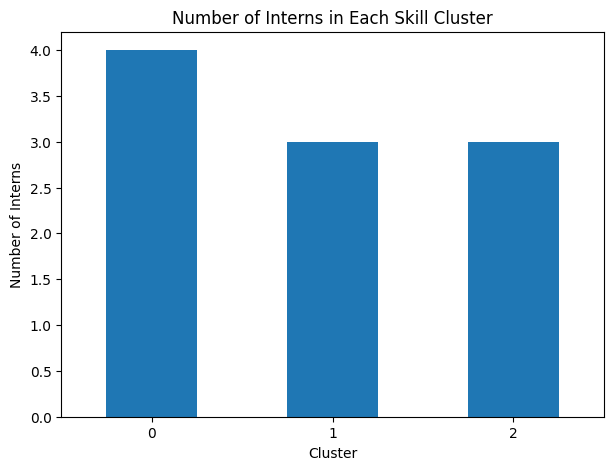

In [23]:
plt.figure(figsize=(7, 5))

cluster_counts.plot(kind="bar")

plt.title("Number of Interns in Each Skill Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Interns")

plt.xticks(rotation=0)

plt.show()

In [24]:
terms = tfidf.get_feature_names_out()

order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for cluster_num in range(k):

    print(f"\nCluster {cluster_num} Top Skills:")

    top_terms = [
        terms[index]
        for index in order_centroids[cluster_num, :10]
    ]

    print(", ".join(top_terms))


Cluster 0 Top Skills:
data, sql, excel, git, analysis, structures, algorithms, spring, java, bi

Cluster 1 Top Skills:
numpy, python, pandas, learning, nlp, tensorflow, deep, learn, scikit, machine

Cluster 2 Top Skills:
html, css, javascript, django, react, mongodb, node, express, js, sql


In [25]:
similarity_matrix = cosine_similarity(
    intern_vectors,
    job_vectors
)

similarity_matrix.shape

(10, 8)

In [26]:
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=interns_df["intern_name"],
    columns=jobs_df["job_title"]
)

similarity_df.round(2)

job_title,Data Scientist,Machine Learning Engineer,Data Analyst,Backend Developer,Frontend Developer,NLP Engineer,Business Intelligence Analyst,Full Stack Developer
intern_name,,,,,,,,
Ali,0.65,0.38,0.22,0.00,0.00,0.28,0.00,0.00
Sara,0.08,0.09,0.09,0.63,0.11,0.00,0.07,0.10
Ahmed,0.00,0.00,0.00,0.00,0.63,0.00,0.00,0.55
Fatima,0.25,0.06,0.40,0.08,0.00,0.06,0.36,0.00
Usman,0.10,0.08,0.10,0.10,0.10,0.00,0.16,0.09
Ayesha,0.51,0.05,0.20,0.00,0.00,0.48,0.00,0.00
Hamza,0.00,0.00,0.00,0.00,0.12,0.00,0.00,0.71
Zainab,0.33,0.56,0.07,0.00,0.00,0.15,0.00,0.00
Bilal,0.29,0.00,0.75,0.07,0.00,0.00,0.69,0.00


In [27]:
best_jobs = []

for i, intern in interns_df.iterrows():

    similarity_scores = similarity_matrix[i]

    best_job_index = similarity_scores.argmax()

    best_job = jobs_df.iloc[best_job_index]["job_title"]

    similarity_score = similarity_scores[best_job_index]

    best_jobs.append(
        {
            "intern_name": intern["intern_name"],
            "best_matching_job": best_job,
            "similarity_score": round(float(similarity_score), 3)
        }
    )

best_jobs_df = pd.DataFrame(best_jobs)

best_jobs_df

,intern_name,best_matching_job,similarity_score
0,Ali,Data Scientist,0.651
1,Sara,Backend Developer,0.632
2,Ahmed,Frontend Developer,0.625
3,Fatima,Data Analyst,0.402
4,Usman,Business Intelligence Analyst,0.163
5,Ayesha,Data Scientist,0.513
6,Hamza,Full Stack Developer,0.708
7,Zainab,Machine Learning Engineer,0.560
8,Bilal,Data Analyst,0.749
9,Hira,Frontend Developer,0.273


In [28]:
interns_df = interns_df.merge(
    best_jobs_df,
    on="intern_name",
    how="left"
)

interns_df[
    [
        "intern_name",
        "skills",
        "cluster",
        "best_matching_job",
        "similarity_score"
    ]
]

,intern_name,skills,cluster,best_matching_job,similarity_score
0,Ali,Python pandas numpy machine learning,1,Data Scientist,0.651
1,Sara,Java SQL Spring Git,0,Backend Developer,0.632
2,Ahmed,HTML CSS JavaScript React,2,Frontend Developer,0.625
3,Fatima,Python SQL data analysis Excel,0,Data Analyst,0.402
4,Usman,C++ algorithms data structures Git,0,Business Intelligence Analyst,0.163
5,Ayesha,Python NLP pandas scikit learn,1,Data Scientist,0.513
6,Hamza,JavaScript Node.js MongoDB Express,2,Full Stack Developer,0.708
7,Zainab,Python TensorFlow deep learning numpy,1,Machine Learning Engineer,0.560
8,Bilal,SQL Power BI Excel data visualization,0,Data Analyst,0.749
9,Hira,Python Django HTML CSS SQL,2,Frontend Developer,0.273


In [29]:
skill_list = [
    "python",
    "java",
    "javascript",
    "html",
    "css",
    "react",
    "node.js",
    "express",
    "mongodb",
    "sql",
    "pandas",
    "numpy",
    "machine learning",
    "deep learning",
    "tensorflow",
    "pytorch",
    "scikit learn",
    "nlp",
    "transformers",
    "bert",
    "docker",
    "git",
    "cloud",
    "spring",
    "rest api",
    "microservices",
    "excel",
    "power bi",
    "tableau",
    "statistics",
    "data visualization"
]

In [30]:
def extract_skills(text, skill_list):

    text = clean_text(text)

    detected_skills = []

    for skill in skill_list:

        if skill.lower() in text:
            detected_skills.append(skill)

    return detected_skills

In [31]:
interns_df["detected_skills"] = interns_df["skills"].apply(
    lambda x: extract_skills(x, skill_list)
)

interns_df[
    ["intern_name", "detected_skills"]
]

,intern_name,detected_skills
0,Ali,"[python, pandas, numpy, machine learning]"
1,Sara,"[java, sql, git, spring]"
2,Ahmed,"[java, javascript, html, css, react]"
3,Fatima,"[python, sql, excel]"
4,Usman,[git]
5,Ayesha,"[python, pandas, scikit learn, nlp]"
6,Hamza,"[java, javascript, node.js, express, mongodb]"
7,Zainab,"[python, numpy, deep learning, tensorflow]"
8,Bilal,"[sql, excel, power bi, data visualization]"
9,Hira,"[python, html, css, sql]"


In [32]:
jobs_df["required_skills"] = jobs_df["job_description"].apply(
    lambda x: extract_skills(x, skill_list)
)

jobs_df[
    ["job_title", "required_skills"]
]

,job_title,required_skills
0,Data Scientist,"[python, sql, pandas, numpy, machine learning,..."
1,Machine Learning Engineer,"[python, machine learning, deep learning, tens..."
2,Data Analyst,"[python, sql, pandas, excel, power bi, tableau..."
3,Backend Developer,"[java, sql, docker, git, spring, rest api, mic..."
4,Frontend Developer,"[java, javascript, html, css, react, git]"
5,NLP Engineer,"[python, machine learning, pytorch, scikit lea..."
6,Business Intelligence Analyst,"[sql, excel, power bi, tableau, data visualiza..."
7,Full Stack Developer,"[java, javascript, html, css, react, node.js, ..."


In [33]:
def calculate_skill_gap(intern_skills, required_skills):

    intern_skills = set(intern_skills)

    required_skills = set(required_skills)

    missing_skills = required_skills - intern_skills

    return sorted(list(missing_skills))

In [34]:
skill_gap_results = []

for _, intern in interns_df.iterrows():

    job_title = intern["best_matching_job"]

    job_row = jobs_df[
        jobs_df["job_title"] == job_title
    ].iloc[0]

    required_skills = job_row["required_skills"]

    intern_skills = intern["detected_skills"]

    missing_skills = calculate_skill_gap(
        intern_skills,
        required_skills
    )

    skill_gap_results.append(
        {
            "intern_name": intern["intern_name"],
            "recommended_job": job_title,
            "existing_skills": intern_skills,
            "required_skills": required_skills,
            "missing_skills": missing_skills
        }
    )

skill_gap_df = pd.DataFrame(skill_gap_results)

skill_gap_df

,intern_name,recommended_job,existing_skills,required_skills,missing_skills
0,Ali,Data Scientist,"[python, pandas, numpy, machine learning]","[python, sql, pandas, numpy, machine learning,...","[data visualization, scikit learn, sql, statis..."
1,Sara,Backend Developer,"[java, sql, git, spring]","[java, sql, docker, git, spring, rest api, mic...","[docker, microservices, rest api]"
2,Ahmed,Frontend Developer,"[java, javascript, html, css, react]","[java, javascript, html, css, react, git]",[git]
3,Fatima,Data Analyst,"[python, sql, excel]","[python, sql, pandas, excel, power bi, tableau...","[data visualization, pandas, power bi, statist..."
4,Usman,Business Intelligence Analyst,[git],"[sql, excel, power bi, tableau, data visualiza...","[data visualization, excel, power bi, sql, tab..."
5,Ayesha,Data Scientist,"[python, pandas, scikit learn, nlp]","[python, sql, pandas, numpy, machine learning,...","[data visualization, machine learning, numpy, ..."
6,Hamza,Full Stack Developer,"[java, javascript, node.js, express, mongodb]","[java, javascript, html, css, react, node.js, ...","[css, git, html, react, rest api]"
7,Zainab,Machine Learning Engineer,"[python, numpy, deep learning, tensorflow]","[python, machine learning, deep learning, tens...","[cloud, docker, git, machine learning, pytorch]"
8,Bilal,Data Analyst,"[sql, excel, power bi, data visualization]","[python, sql, pandas, excel, power bi, tableau...","[pandas, python, statistics, tableau]"
9,Hira,Frontend Developer,"[python, html, css, sql]","[java, javascript, html, css, react, git]","[git, java, javascript, react]"


In [35]:
skill_gap_df["number_of_missing_skills"] = skill_gap_df[
    "missing_skills"
].apply(len)

skill_gap_df[
    [
        "intern_name",
        "recommended_job",
        "missing_skills",
        "number_of_missing_skills"
    ]
]

,intern_name,recommended_job,missing_skills,number_of_missing_skills
0,Ali,Data Scientist,"[data visualization, scikit learn, sql, statis...",4
1,Sara,Backend Developer,"[docker, microservices, rest api]",3
2,Ahmed,Frontend Developer,[git],1
3,Fatima,Data Analyst,"[data visualization, pandas, power bi, statist...",5
4,Usman,Business Intelligence Analyst,"[data visualization, excel, power bi, sql, tab...",5
5,Ayesha,Data Scientist,"[data visualization, machine learning, numpy, ...",5
6,Hamza,Full Stack Developer,"[css, git, html, react, rest api]",5
7,Zainab,Machine Learning Engineer,"[cloud, docker, git, machine learning, pytorch]",5
8,Bilal,Data Analyst,"[pandas, python, statistics, tableau]",4
9,Hira,Frontend Developer,"[git, java, javascript, react]",4


In [36]:
def calculate_readiness(existing_skills, required_skills):

    existing = set(existing_skills)

    required = set(required_skills)

    if len(required) == 0:
        return 0

    matched = existing.intersection(required)

    score = len(matched) / len(required) * 100

    return round(score, 2)

In [37]:
skill_gap_df["readiness_score"] = skill_gap_df.apply(
    lambda row: calculate_readiness(
        row["existing_skills"],
        row["required_skills"]
    ),
    axis=1
)

skill_gap_df[
    [
        "intern_name",
        "recommended_job",
        "readiness_score",
        "missing_skills"
    ]
]

,intern_name,recommended_job,readiness_score,missing_skills
0,Ali,Data Scientist,50.00,"[data visualization, scikit learn, sql, statis..."
1,Sara,Backend Developer,57.14,"[docker, microservices, rest api]"
2,Ahmed,Frontend Developer,83.33,[git]
3,Fatima,Data Analyst,37.50,"[data visualization, pandas, power bi, statist..."
4,Usman,Business Intelligence Analyst,0.00,"[data visualization, excel, power bi, sql, tab..."
5,Ayesha,Data Scientist,37.50,"[data visualization, machine learning, numpy, ..."
6,Hamza,Full Stack Developer,50.00,"[css, git, html, react, rest api]"
7,Zainab,Machine Learning Engineer,37.50,"[cloud, docker, git, machine learning, pytorch]"
8,Bilal,Data Analyst,50.00,"[pandas, python, statistics, tableau]"
9,Hira,Frontend Developer,33.33,"[git, java, javascript, react]"


In [38]:
training_map = {

    "python": "Complete Python for Data Science training",

    "java": "Complete Java Programming course",

    "javascript": "Learn modern JavaScript ES6+",

    "react": "Complete React Frontend Development course",

    "sql": "Complete SQL and Database Fundamentals",

    "pandas": "Practice Pandas for Data Analysis",

    "numpy": "Learn NumPy fundamentals",

    "machine learning": "Complete Machine Learning fundamentals",

    "deep learning": "Complete Deep Learning specialization",

    "tensorflow": "Complete TensorFlow training",

    "pytorch": "Learn PyTorch fundamentals",

    "scikit learn": "Practice Scikit-learn machine learning",

    "nlp": "Complete Natural Language Processing course",

    "transformers": "Learn Hugging Face Transformers",

    "bert": "Study BERT and transformer models",

    "docker": "Complete Docker fundamentals",

    "git": "Learn Git and GitHub",

    "cloud": "Study cloud deployment fundamentals",

    "spring": "Complete Spring Boot training",

    "rest api": "Learn REST API development",

    "microservices": "Study Microservices architecture",

    "excel": "Complete Advanced Excel training",

    "power bi": "Complete Power BI certification training",

    "tableau": "Learn Tableau data visualization",

    "statistics": "Study statistics for data science",

    "data visualization": "Practice data visualization techniques"
}

In [39]:
def recommend_training(missing_skills):

    recommendations = []

    for skill in missing_skills:

        if skill in training_map:

            recommendations.append(
                training_map[skill]
            )

        else:

            recommendations.append(
                f"Complete training in {skill}"
            )

    return recommendations

In [40]:
skill_gap_df["training_recommendations"] = skill_gap_df[
    "missing_skills"
].apply(recommend_training)

skill_gap_df[
    [
        "intern_name",
        "recommended_job",
        "missing_skills",
        "training_recommendations"
    ]
]

,intern_name,recommended_job,missing_skills,training_recommendations
0,Ali,Data Scientist,"[data visualization, scikit learn, sql, statis...","[Practice data visualization techniques, Pract..."
1,Sara,Backend Developer,"[docker, microservices, rest api]","[Complete Docker fundamentals, Study Microserv..."
2,Ahmed,Frontend Developer,[git],[Learn Git and GitHub]
3,Fatima,Data Analyst,"[data visualization, pandas, power bi, statist...","[Practice data visualization techniques, Pract..."
4,Usman,Business Intelligence Analyst,"[data visualization, excel, power bi, sql, tab...","[Practice data visualization techniques, Compl..."
5,Ayesha,Data Scientist,"[data visualization, machine learning, numpy, ...","[Practice data visualization techniques, Compl..."
6,Hamza,Full Stack Developer,"[css, git, html, react, rest api]","[Complete training in css, Learn Git and GitHu..."
7,Zainab,Machine Learning Engineer,"[cloud, docker, git, machine learning, pytorch]","[Study cloud deployment fundamentals, Complete..."
8,Bilal,Data Analyst,"[pandas, python, statistics, tableau]","[Practice Pandas for Data Analysis, Complete P..."
9,Hira,Frontend Developer,"[git, java, javascript, react]","[Learn Git and GitHub, Complete Java Programmi..."


In [41]:
all_missing_skills = []

for skills in skill_gap_df["missing_skills"]:

    all_missing_skills.extend(skills)

missing_skill_counts = pd.Series(
    all_missing_skills
).value_counts()

missing_skill_counts

data visualization    4
statistics            4
git                   4
sql                   3
tableau               3
docker                2
rest api              2
pandas                2
power bi              2
machine learning      2
react                 2
scikit learn          1
microservices         1
excel                 1
numpy                 1
css                   1
html                  1
cloud                 1
pytorch               1
python                1
java                  1
javascript            1
Name: count, dtype: int64

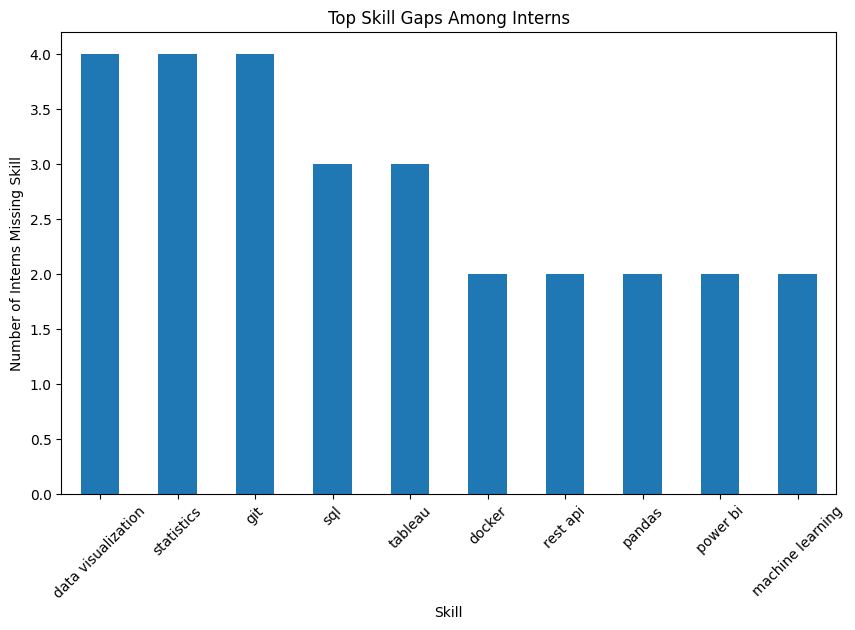

In [42]:
plt.figure(figsize=(10, 6))

missing_skill_counts.head(10).plot(
    kind="bar"
)

plt.title("Top Skill Gaps Among Interns")
plt.xlabel("Skill")
plt.ylabel("Number of Interns Missing Skill")

plt.xticks(rotation=45)

plt.show()

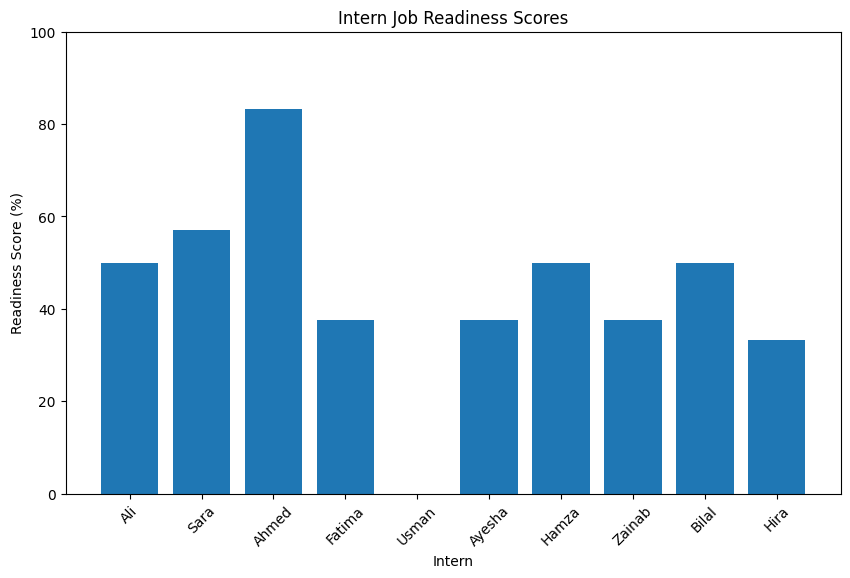

In [43]:
plt.figure(figsize=(10, 6))

plt.bar(
    skill_gap_df["intern_name"],
    skill_gap_df["readiness_score"]
)

plt.title("Intern Job Readiness Scores")
plt.xlabel("Intern")
plt.ylabel("Readiness Score (%)")

plt.xticks(rotation=45)

plt.ylim(0, 100)

plt.show()

In [44]:
def analyze_intern(intern_name):

    result = skill_gap_df[
        skill_gap_df["intern_name"].str.lower()
        == intern_name.lower()
    ]

    if result.empty:

        print("Intern not found.")

        return

    row = result.iloc[0]

    print("=" * 50)
    print("SKILL GAP ANALYSIS REPORT")
    print("=" * 50)

    print("Intern:", row["intern_name"])

    print(
        "Recommended Job:",
        row["recommended_job"]
    )

    print(
        "Readiness Score:",
        str(row["readiness_score"]) + "%"
    )

    print(
        "\nExisting Skills:"
    )

    for skill in row["existing_skills"]:
        print("-", skill)

    print(
        "\nMissing Skills:"
    )

    for skill in row["missing_skills"]:
        print("-", skill)

    print(
        "\nRecommended Training:"
    )

    for course in row["training_recommendations"]:
        print("-", course)

In [45]:
analyze_intern("Ali")

SKILL GAP ANALYSIS REPORT
Intern: Ali
Recommended Job: Data Scientist
Readiness Score: 50.0%

Existing Skills:
- python
- pandas
- numpy
- machine learning

Missing Skills:
- data visualization
- scikit learn
- sql
- statistics

Recommended Training:
- Practice data visualization techniques
- Practice Scikit-learn machine learning
- Complete SQL and Database Fundamentals
- Study statistics for data science


In [46]:
def compare_intern_with_job(intern_name, job_title):

    intern_row = interns_df[
        interns_df["intern_name"].str.lower()
        == intern_name.lower()
    ]

    job_row = jobs_df[
        jobs_df["job_title"].str.lower()
        == job_title.lower()
    ]

    if intern_row.empty:
        print("Intern not found.")
        return

    if job_row.empty:
        print("Job not found.")
        return

    intern_skills = intern_row.iloc[0]["detected_skills"]

    required_skills = job_row.iloc[0]["required_skills"]

    missing_skills = calculate_skill_gap(
        intern_skills,
        required_skills
    )

    readiness = calculate_readiness(
        intern_skills,
        required_skills
    )

    training = recommend_training(
        missing_skills
    )

    print("=" * 55)

    print("INTERN VS JOB SKILL GAP REPORT")

    print("=" * 55)

    print(
        f"Intern: {intern_name}"
    )

    print(
        f"Target Job: {job_title}"
    )

    print(
        f"Readiness Score: {readiness}%"
    )

    print("\nIntern Skills:")

    for skill in intern_skills:
        print("-", skill)

    print("\nRequired Skills:")

    for skill in required_skills:
        print("-", skill)

    print("\nSkill Gaps:")

    for skill in missing_skills:
        print("-", skill)

    print("\nTraining Recommendations:")

    for recommendation in training:
        print("-", recommendation)

In [47]:
compare_intern_with_job(
    "Ali",
    "NLP Engineer"
)

INTERN VS JOB SKILL GAP REPORT
Intern: Ali
Target Job: NLP Engineer
Readiness Score: 28.57%

Intern Skills:
- python
- pandas
- numpy
- machine learning

Required Skills:
- python
- machine learning
- pytorch
- scikit learn
- nlp
- transformers
- bert

Skill Gaps:
- bert
- nlp
- pytorch
- scikit learn
- transformers

Training Recommendations:
- Study BERT and transformer models
- Complete Natural Language Processing course
- Learn PyTorch fundamentals
- Practice Scikit-learn machine learning
- Learn Hugging Face Transformers


In [48]:
def recommend_jobs(intern_name, top_n=3):

    intern_index_list = interns_df.index[
        interns_df["intern_name"].str.lower()
        == intern_name.lower()
    ].tolist()

    if not intern_index_list:

        print("Intern not found.")
        return

    intern_index = intern_index_list[0]

    scores = similarity_matrix[intern_index]

    top_indices = scores.argsort()[::-1][:top_n]

    results = []

    for index in top_indices:

        results.append(
            {
                "job_title": jobs_df.iloc[index]["job_title"],

                "similarity_score": round(
                    float(scores[index]) * 100,
                    2
                )
            }
        )

    return pd.DataFrame(results)

In [49]:
recommend_jobs("Ali")

,job_title,similarity_score
0,Data Scientist,65.10
1,Machine Learning Engineer,38.13
2,NLP Engineer,27.96


In [50]:
training_priority = (
    missing_skill_counts
    .reset_index()
)

training_priority.columns = [
    "skill",
    "number_of_interns_missing_skill"
]

training_priority

,skill,number_of_interns_missing_skill
0,data visualization,4
1,statistics,4
2,git,4
3,sql,3
4,tableau,3
5,docker,2
6,rest api,2
7,pandas,2
8,power bi,2
9,machine learning,2


In [51]:
training_priority["recommended_training"] = (
    training_priority["skill"]
    .apply(
        lambda skill: training_map.get(
            skill,
            f"Training in {skill}"
        )
    )
)

training_priority

,skill,number_of_interns_missing_skill,recommended_training
0,data visualization,4,Practice data visualization techniques
1,statistics,4,Study statistics for data science
2,git,4,Learn Git and GitHub
3,sql,3,Complete SQL and Database Fundamentals
4,tableau,3,Learn Tableau data visualization
5,docker,2,Complete Docker fundamentals
6,rest api,2,Learn REST API development
7,pandas,2,Practice Pandas for Data Analysis
8,power bi,2,Complete Power BI certification training
9,machine learning,2,Complete Machine Learning fundamentals


In [52]:
skill_gap_df.to_csv(
    "skill_gap_analysis_results.csv",
    index=False
)

training_priority.to_csv(
    "training_priorities.csv",
    index=False
)

best_jobs_df.to_csv(
    "job_recommendations.csv",
    index=False
)

print("All results saved successfully.")

All results saved successfully.


In [53]:
print("=" * 60)

print("SKILL GAP ANALYSIS SYSTEM SUMMARY")

print("=" * 60)

print(
    "Total Interns:",
    len(interns_df)
)

print(
    "Total Industry Jobs:",
    len(jobs_df)
)

print(
    "Skill Clusters:",
    k
)

print(
    "Average Readiness Score:",
    round(
        skill_gap_df["readiness_score"].mean(),
        2
    ),
    "%"
)

print("\nMost Common Skill Gaps:")

print(
    missing_skill_counts.head(5)
)

SKILL GAP ANALYSIS SYSTEM SUMMARY
Total Interns: 10
Total Industry Jobs: 8
Skill Clusters: 3
Average Readiness Score: 43.63 %

Most Common Skill Gaps:
data visualization    4
statistics            4
git                   4
sql                   3
tableau               3
Name: count, dtype: int64
